实验追踪与可视化看板工具 —— Weights & Biases (简称 W&B，也叫 WandB)。

为什么要用 W&B？它解决了什么痛点？

在没有 W&B 之前，我们通常用 TensorBoard 或者自己写 print 打印 Loss，这会带来几个灾难性的痛苦：

本地查看的局限性：你在服务器、云端 A100 上跑训练，TensorBoard 的日志在远端，你需要折腾复杂的 SSH 端口转发（Port Forwarding）才能在本地浏览器看到曲线。

多实验对比极其恶心：当你想对比“实验 A（lr=0.01）”和“实验 B（lr=0.001）”的验证集准确率时，TensorBoard 的曲线经常挤在一起，很难做复杂的纵向和横向筛选。

数据丢失风险：一旦服务器挂了或者断电，如果没有及时保存日志，你可能根本不知道模型在崩溃前跑到了什么水平。

W&B 是一座架设在云端的“终极实验仪表盘”。 你只需要在代码里加几行日志埋点，它就会把训练过程中的所有数据（Loss、准确率、显存占用、甚至模型生成的图片、文本）实时同步到云端。你可以用手机、电脑随时随地查看极其美观的图表。

在**最一般、最普遍**的情况下，作为个人开发者、高校学生或者科研人员，你需要去官方网站注册一个账号。

整个常规流程只需要 3 步，非常简单，完全免费：

1. **注册**：登录官方网站 [wandb.ai](https://www.google.com/search?q=https://wandb.ai)，用你的 GitHub 账号、Google 账号或者邮箱直接注册。
2. **拿钥匙（API Key）**：注册登录后，你会获得一串专属的、由字母和数字组成的“API Key”（相当于连接你本地代码和云端大屏幕的钥匙）。
3. **绑定**：在你的 Linux 服务器或本地终端输入 `wandb login`，把这串 API Key 复制粘贴进去回车。

只要绑定过这一次，以后你在这台机器上跑任何 PyTorch 代码，W&B 都会自动把你代码里的 Loss 曲线同步到你刚刚注册的这个账号的网页后台。

首先需要新建team，然后在team里新建project,然后是基于这个team和project会给出初始化的示例代码：
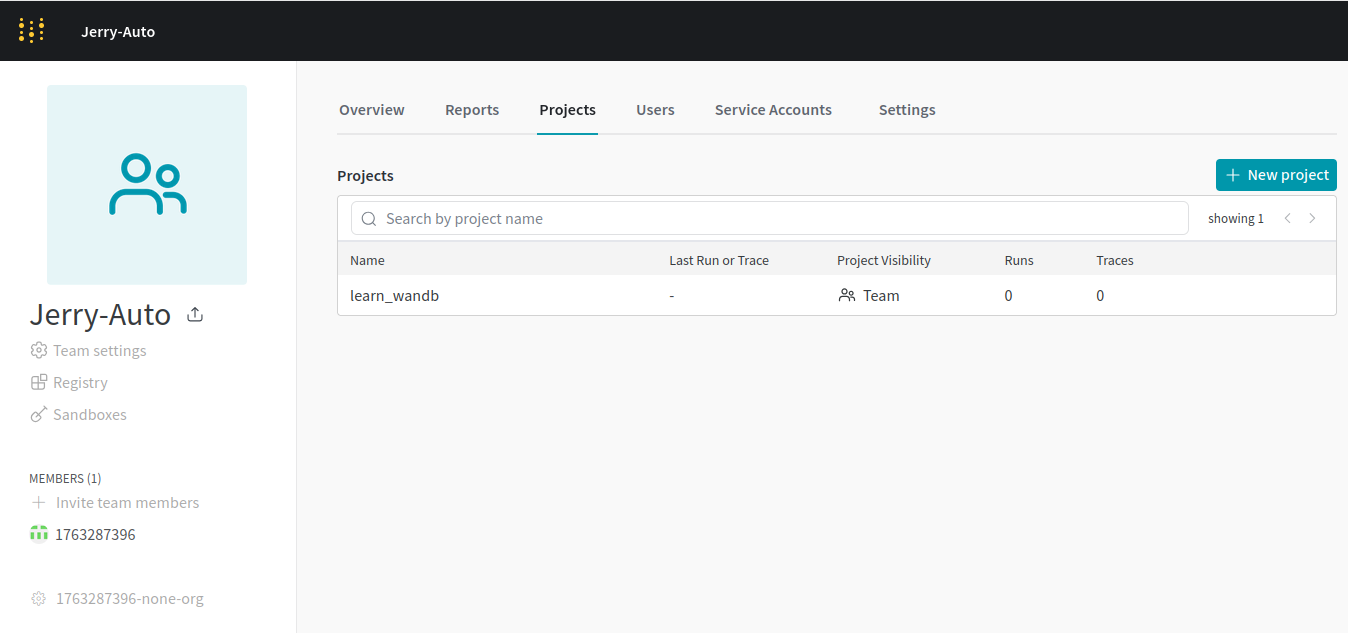

In [2]:
import random

import wandb

# Start a new wandb run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="Jerry-Auto",
    # Set the wandb project where this run will be logged.
    project="learn_wandb",
    # Track hyperparameters and run metadata.
    config={
        "learning_rate": 0.02,
        "architecture": "CNN",
        "dataset": "CIFAR-100",
        "epochs": 10,
    },
)

# Simulate training.
epochs = 10
offset = random.random() / 5
for epoch in range(2, epochs):
    acc = 1 - 2**-epoch - random.random() / epoch - offset
    loss = 2**-epoch + random.random() / epoch + offset

    # Log metrics to wandb.
    run.log({"acc": acc, "loss": loss})

# Finish the run and upload any remaining data.
run.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/zhangjinrui/.netrc.
wandb: Currently logged in as: 1763287396 (Jerry-Auto) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
/home/zhangjinrui/anaconda3/envs/flow_planner/lib/python3.9/site-packages/pydantic/main.py:301: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


acc,▁▆▇█▇▇█▇
loss,█▇▅▅▃▁▁▂
acc,0.74662
loss,0.2287



---

## 💡 什么时候“不需要”注册官方账号？

只有在以下两种特殊或高级的工程场景下，你才不需要去注册官方账号：

### 1. 纯本地单机玩玩（离线模式）

如果你只是想临时试一下它的代码能不能跑通，或者所在的实验室完全封闭、没有外网。你可以直接在终端敲：

```bash
export WANDB_MODE=offline

```

此时你**不需要任何账号**，直接运行代码，它会将所有数据规规矩矩地存在你本地硬盘的一个叫 `wandb/` 的文件夹里。

### 2. 你的公司或实验室部署了“私有局域网版本”

如果是去一些大型 AI 企业（或者财力雄厚的顶尖科研所）实习或工作，出于数据保密原因，公司内部会搭建一个独立的局域网 W&B 服务器。
这时候你**不需要去外网注册账号**，而是直接访问公司内部的局域网网址（比如 `http://wandb.internal.company.com`），在公司内部的系统里直接登录或开通账号即可。

W&B 在工程上不仅仅是一个“画曲线的网站”，它是一套完整的 **MLOps（机器学习运维）基础设施**。它的核心体系由四个部分组成：**Runs（实验追踪）**、**Artifacts（产物与版本控制）**、**Sweeps（超参自动化搜索）** 和 **Reports（动态报告）**。

---

## 一、 W&B 的四大核心支柱

### 1. Runs（基础实验追踪）

这是最常用的部分。每一次你运行 `python train.py`，W&B 就会在云端创建一个独一无二的 **Run ID**。这个 Run 会死死盯住你的进程，实时抓取你的指标、系统硬件指标（DDP 模式下甚至能抓取每张卡的显存和通信状态）、控制台的标准输出（`stdout` / `stderr`）以及报错信息。

### 2. Artifacts（模型与数据集版本控制）

这是工业界极度看重的功能。传统的 `torch.save(model.state_dict(), 'best.pt')` 很容易重名或者搞混。
W&B 的 Artifacts 就像是**针对大数据、大模型的 Git**。它可以把你的数据集、训练好的模型 Checkpoint 自动上传到云端，并打上版本号（如 `v0`, `v1`, `latest`），甚至会**自动生成血统图（Lineage Graph）**，清晰地展示“这个模型是用哪一个数据集、哪一次 Run 训练出来的”。

### 3. Sweeps（自动化超参调优）

你不需要自己写 `for` 循环或者用 shell 脚本去试参数。Sweeps 允许你在云端定义一个搜索空间（比如学习率在 `1e-4` 到 `1e-2` 之间，优化器选 `AdamW` 或 `SGD`），W&B 会自动调度你的多台服务器，采用 **贝叶斯优化（Bayesian Optimization）**、**随机搜索** 或 **网格搜索** 自动帮你寻找最优超参组合，并带有**早停机制（Hyperband）**，发现模型跑崩了会自动掐断，省钱省时。

### 4. Reports（团队协作与技术沉淀）

它可以将你不同时期、不同项目跑出来的动态图表一键拖拽组合在一起。你可以在图表旁边写 Markdown Markdown 注释、插入数学公式，生成一个精美的在线网页。




---

## 一、 实验追踪的标准使用流程

W&B 实验追踪在代码中遵循一个极简的、确定性的**三步生命周期**：

1. **`wandb.init()`（初始化阶段）**：在代码最前端调用，通知 W&B 云端服务器创建一个新的、隔离的实验记录（Run），并配置好这个实验的名称、分组和归属。
2. **`wandb.log()` / `wandb.watch()`（运行记录阶段）**：在模型的训练循环（Training Loop）或评估代码中，高频调用这些 API。
* `wandb.log()` 负责将数字（折线图）和各种包装好的多媒体文件实时推送到云端。
* `wandb.watch()` 负责静默挂载到 PyTorch 模型上，自动抓取底层梯度。


3. **`wandb.finish()`（退出销毁阶段）**：在代码最后调用，阻塞主线程并把缓存中剩余的数据彻底同步到云端，安全关闭该实验。

---

### 核心 API、参数及网页端效果详解

### 1. `wandb.init()` —— 实验生命周期初始化

此 API 负责在云端注册当前运行的实例，并定义它在网页端后台的归属和展示方式。

#### 核心参数：

* **`project`** *(str)*：项目名称。网页端会将相同 project 的实验聚合在一个大看板内。
* **`entity`** *(str)*：团队或组织名称。如果填写，实验会同步到团队公共空间，便于多人协同查看；不填则默认存入个人空间。
* **`name`** *(str)*：单次实验的展示名称。如果不指定，W&B 会随机生成一个搞笑的英文名字（如 `vocal-glade-4`）。
* **`group`** *(str)*：实验分组标签。用于把做同一种实验、但换了不同随机种子的多个 Run 聚合在一起。
* **`job_type`** *(str)*：任务类型标签（如 `"training"`、`"evaluation"`），用于在网页端过滤表格。
* **`dir`** *(str/Path)*：指定 W&B 在**本地**写入缓存日志的文件夹路径。
* **`notes`** *(str)*：对这次实验的长篇文字备注或描述。
* **`reinit`** *(bool)*：是否允许重复初始化。如果设为 `True`，在同一个 Python 进程里前面一个 Run 结束后，可以再次调用 `init()` 开启新 Run。

#### 网页端对应的可视化效果：

* 网页后台会生成一条独立的实验记录（Run）。
* 在左侧的实验列表中，所有 Run 会优先按照 `group` 进行折叠聚合。点击进去后，可以看到完整的 `notes` 描述以及运行该实验的物理机器机器名。

---

### 2. `wandb.log()` —— 数据与多媒体交互画布

此 API 是最高频使用的接口，用于将本地的数据、图表、多媒体资产结构化地发送至云端。

#### 核心参数：

* **`data`** *(dict)*：必填。字典的 Key 为网页端图表的名称，Value 可以是数字（Scalar），也可以是 W&B 特有的多媒体包装对象。
* **`step`** *(int)*：选填。**极重要参数（物理时间轴）**。如果不填，W&B 内部会有一个自增的计数器作为 X 轴；如果填了，云端所有的图表都将严格以你指定的 `step` 作为 X 轴对齐。

#### 多媒体包装对象参数及效果：

| 包装对象 API | 核心入参 | 网页端呈现的效果 |
| --- | --- | --- |
| **`wandb.Html()`** | `html_str` *(字符串)* 或 `file` *(本地HTML文件)* | 在网页看板上直接渲染出一个**可点击、可交互的富文本/网页组件**，甚至可以内嵌超链接。 |
| **`wandb.Image()`** | `data` *(Numpy数组/Torch张量/PIL图片)*, `caption` *(标题)* | 在网页端展现为**图片瀑布流**。鼠标悬浮可放大，并能看到你设置的 `caption` 标签。 |
| **`wandb.Video()`** | `data` *(4D张量: [T, C, H, W])* , `fps` *(每秒帧数)*, `format` *("gif"或"mp4")* | 在网页端直接生成一个**内置的视频播放器或动图**。可以直接点击播放、暂停、进度条拖动，直观观测时序图像变化。 |
| **`wandb.Plotly()`** | `matplotlib_figure` *(matplotlib的gcf()对象)* | 将原本扁平、静态的 matplotlib 图片，在网页端**自动无缝升级为交互式 Plotly 图表**。支持鼠标悬浮显示精准数值、局部放大、拉伸缩放。 |
| **`wandb.Table()`** | `data` *(二维列表)*, `columns` *(列名列表)* | 在网页端直接生成一个**网页版 Excel 表格**。你可以在网页上直接对每一列进行 `Sort`（排序）、`Filter`（条件过滤）、`Group`（聚合分组）。 |

---

### 3. `wandb.watch()` —— 网络梯度静默监视器

这是一个专门针对深度学习（如 PyTorch）的 Hook 挂载工具。

#### 核心参数：

* **`models`** *(nn.Module)*：你需要监控的 PyTorch 模型实例。
* **`log_freq`** *(int)*：记录频率。例如设为 `1`，代表每隔 1 个训练 Step 就去抓取一次底层数据。

#### 网页端对应的可视化效果：

* 自动在云端为你画出当前模型的**网络拓扑结构图**。
* 在图表区自动生成 **"Gradients"（梯度）** 和 **"Parameters"（参数/权重）** 的专属面板。以**3D直方图或热力图**的形式，实时展示网络每一层的权重数值分布和梯度流动情况。你可以一眼看出哪一层的梯度死掉了（变为0），或者哪一层的参数炸了。

---

### 4. `wandb.finish()` —— 显式安全终止

该 API 没有复杂的业务参数，它扮演的是生命周期的“守门人”。

#### 运行效果：

* 此时程序会暂停退出，终端会弹出一个进度条，显示：`"Syncing run ..."`。
* 强制将本地双缓冲队列中、或者尚未发送完毕的大体积视频、图片、表格文件**彻底同步上传至云端**。
* 同步完成后，会在本地终端打印出这次实验的云端 URL 访问链接，以及本次实验的核心指标摘要（Summary），随后安全释放网络连接和系统进程。

在机器学习工程中，出于**保护数据隐私（代码/数据不出网）**或者**在无网、弱网环境（如超算集群、封闭机房）下运行**的需要，W&B 提供了一套完整的**离线/本地运行机制（Offline Mode）**。

当开启离线模式后，W&B 的所有功能（包括多媒体打包、表格生成、梯度追踪）完全照常运行，但数据**只写入本地磁盘**，绝不向云端服务器发送任何网络请求。

---

#### 切换为本地离线模式的方法

在代码中，只需通过一行配置将运行模式（`mode`）显式设置为 `"offline"` 即可：

```python
# 核心设置：将 mode 设置为 "offline"
wandb.init(mode="offline", ...)

```

运行结束后，所有日志会保存在你指定的本地目录（`dir`）或默认的 `./wandb` 文件夹下。

> **💡 提示：** 离线运行产生的本地文件夹，后续如果想同步到云端，随时可以在终端执行命令：`wandb sync ./wandb/offline-run-xxxx`。


In [1]:
# =====================================================================
# 【核心关键】：强行为旧版 pydantic_core 注入缺失的 from_json 接口
# =====================================================================
import pydantic_core
import json
# 环境会冲突，导致旧版本的 pydantic_core 没有 from_json 接口，无法正确序列化日志数据
# 这里做一个兼容性补丁：如果发现 pydantic_core 没有 from_json，就用标准库的 json.loads 来伪装成 from_json 挂载上去
if not hasattr(pydantic_core, 'from_json'):
    # 用标准库的 json.loads 伪装成 from_json 挂载上去
    pydantic_core.from_json = lambda s: json.loads(s if isinstance(s, str) else s.decode('utf-8'))
    print("✨ 已成功为旧版 pydantic_core 注入兼容性补丁！Lightning 和 Table 均已保住！")

import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import wandb

# =====================================================================
# 1. 定义一个用于测试梯度追踪的简单 PyTorch 模型
# =====================================================================
class LocalSimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 5)  # 隐藏层
        self.fc2 = nn.Linear(5, 2)   # 输出层
    def forward(self, x):
        return self.fc2(torch.tanh(self.fc1(x)))

def run_local_tracking_demo():
    print("开始本地离线实验初始化...")
    
    # =====================================================================
    # 2. 初始化阶段 (wandb.init) -> 核心：配置为 offline 离线模式
    # =====================================================================
    run = wandb.init(
        mode="offline",                           # 【关键点】设置为离线模式，完全不联网、不上传
        project="local_pure_testing",            # 本地项目大类文件夹名称
        name="offline_all_api_run",               # 本次本地实验的名字
        group="offline_group",                    # 实验分组标签
        job_type="local_benchmark",               # 任务类型标签
        notes="此实验完全在本地运行，数据不离机，包含全套多媒体API测试", # 实验详细备注
        dir="./wandb_offline_storage",            # 指定本地日志和媒体文件的缓存根目录
        reinit=True                               # 允许在同一个脚本中多次初始化Run
    )

    # =====================================================================
    # 3. 模型挂载阶段 (wandb.watch) -> 隐式监听底层权重与梯度
    # =====================================================================
    model = LocalSimpleNet()
    # log_freq=1 表示每隔 1 个训练 Step，就在本地日志中记录一次每一层的权重和梯度直方图
    wandb.watch(model, log_freq=1)

    # =====================================================================
    # 4. 数据与多媒体流记录阶段 (wandb.log) 
    # =====================================================================
    
    # 【提前准备：交互式表格初始化】
    # 先在外部创建一张空的结构化表格，并定义好三个列名
    local_eval_table = wandb.Table(columns=["训练步数(Step)", "捕获图像(Image)", "随机状态码"])
    
    total_steps = 5
    for step in range(total_steps):
        print(f"--> 正在执行本地循环：第 {step} 步...")
        
        # --- A. 基础标量数据 (折线图数字) ---
        simulated_loss = 2.0 / (step + 1) + random.uniform(-0.02, 0.02)
        simulated_acc = 0.6 + (step * 0.08)

        # --- B. 图像数据包装 (wandb.Image) ---
        # 模拟生成一个 28x28 的 Numpy 随机矩阵（代表一张灰度图）
        mock_image = np.random.rand(28, 28)
        # 将 Numpy 数组包装为 W&B 的图像对象，并附带说明文字
        wandb_image_obj = wandb.Image(mock_image, caption=f"本地图片_Step_{step}")

        # --- C. 视频数据包装 (wandb.Video) ---
        # 模拟生成一个视频张量，形状必须为 4维: [时间帧数, 通道数, 高度, 宽度]
        # 这里模拟 8 帧画面、3个通道（RGB）、32x32 分辨率的动态矩阵
        mock_video = np.random.rand(8, 3, 32, 32)
        # 包装为视频对象，设置每秒播放 4 帧，格式为本地兼容性最好的 gif
        wandb_video_obj = wandb.Video(mock_video, fps=4, format="gif", caption=f"本地视频_{step}")

        # --- D. 交互式图表包装 (wandb.Plotly) ---
        plt.figure()
        plt.plot([0, 1, 2], [5, 5 + step, 5 - step], label=f"Line-{step}")
        plt.title("Local Matplotlib Figure")
        # 【核心转换】将本地 matplotlib 的静态图片，转化为富交互的 Plotly 数据格式保存
        wandb_plotly_obj = wandb.Plotly(plt.gcf())
        plt.close() # 及时释放 matplotlib 的本地内存，防止内存泄漏

        # --- E. 逐步追加数据到表格中 (wandb.Table) ---
        # 将当前的步数、上面做好的图片对象、以及一串文字，作为一行追加到表格里
        local_eval_table.add_data(step, wandb_image_obj, f"Offline_Code_{random.randint(1000, 2000)}")

        # --- F. 模拟 PyTorch 反向传播以激活梯度 ---
        mock_input = torch.randn(1, 10)
        mock_output = model(mock_input)
        loss = mock_output.sum()
        loss.backward() # 触发现底层的梯度计算，上一阶段的 wandb.watch 会自动在后台捕获这些梯度

        # --- G. 统一调用 log 发送本步的所有混合资产 ---
        # 所有数据会被打包写入到本地的 `./wandb_offline_storage` 文件夹中
        wandb.log({
            "scalars/loss": simulated_loss,            # 标量：损失值曲线
            "scalars/accuracy": simulated_acc,         # 标量：准确率曲线
            "media/static_image": wandb_image_obj,     # 媒体：单张图片
            "media/animated_video": wandb_video_obj,   # 媒体：视频/动图
            "charts/interactive_plot": wandb_plotly_obj,# 图表：Plotly对象
        }, step=step) # 【重要】显式绑定当前的 Step 作为物理时间轴

    # 【循环结束后：记录全局一次性大资产】
    
    # --- H. 富文本组件包装 (wandb.Html) ---
    # 模拟编写一段 HTML 富文本代码段
    html_string = '<h2 style="color: #FF5733;">离线测试完毕</h2><p>本地数据已全部成功格式化序列化。</p>'
    wandb_html_obj = wandb.Html(html_string)
    
    # 将最终填满数据的交互式表格、以及HTML报告一次性写入本地日志
    wandb.log({
        "reports/local_html_summary": wandb_html_obj,
        "tables/final_compiled_table": local_eval_table
    })

    # =====================================================================
    # 5. 退出销毁阶段 (wandb.finish) -> 安全断开并保存本地资产
    # =====================================================================
    wandb.finish()
    print("\n====================================================================")
    print("【本地运行完成】所有日志、图片、视频和表格已安全写入本地目录：")
    print(f" 路径: ./wandb_offline_storage/wandb/")
    print(" 提示: 此时完全没有网络连接，数据100%保存在本地。")
    print("====================================================================")

✨ 已成功为旧版 pydantic_core 注入兼容性补丁！Lightning 和 Table 均已保住！


In [3]:
run_local_tracking_demo()

开始本地离线实验初始化...


/home/zhangjinrui/anaconda3/envs/flow_planner/lib/python3.9/site-packages/pydantic/main.py:301: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


--> 正在执行本地循环：第 0 步...


--> 正在执行本地循环：第 1 步...


--> 正在执行本地循环：第 2 步...


--> 正在执行本地循环：第 3 步...


--> 正在执行本地循环：第 4 步...


scalars/accuracy,▁▃▄▆█
scalars/loss,█▄▂▁▁
scalars/accuracy,0.92
scalars/loss,0.41451



【本地运行完成】所有日志、图片、视频和表格已安全写入本地目录：
 路径: ./wandb_offline_storage/wandb/
 提示: 此时完全没有网络连接，数据100%保存在本地。


既然是**纯本地离线模式（Offline Mode）**，W&B 不会把数据传到云端，因此你直接刷新 wandb.ai 网站是看不到结果的。

要查看本地离线实验的结果，业界最标准的做法是**在本地启动 W&B 的内置本地看板（W&B Board / local view）**，或者直接将本地数据同步到你个人的云端账号。

以下是具体的两种查看方式：

---

### 方法一：最标准做法，用 `wandb server` 启动本地看板（推荐）

W&B 官方提供的本地免费看版服务叫 `wandb server`（或者在旧版本中叫 `wandb local`）。它会在你的机器上本地用 Docker 镜像拉起一个完整的、不需要联网的网页端。

在终端中执行：

```bash
wandb server start

```

* **效果**：它会在本地启动一个容器，成功后会在终端打印出 `http://localhost:8080`。
* **怎么看**：用浏览器打开这个网址，你就能看到一个完全运行在本地、极其炫酷的控制台，里面包含了你跑完的所有离线实验。

很难弄，还要做一个容器，建议是直接用pyhton脚本读取输出结果，然后可视化，或者使用方法二同步到云端然后直接查看即可

---

## 方案二：等有网了，或者想传到云端看（一键同步）

如果你现在本地跑完了，想把这个离线记录上传到 W&B 云端个人后台，保存并分享给别人，W&B 提供了一条**一键逆向同步**命令。

### 步骤 1：找到你刚才跑完的离线文件夹

去你的 `dir` 参数指定的目录下（比如代码里的 `./wandb_offline_storage`），你会看到里面有一个形如 `offline-run-YYYYMMDD_HHMMSS-xxxxxx` 的文件夹。

### 步骤 2：在终端执行同步命令

在终端里运行 `wandb sync` 并加上这个文件夹的路径：

```bash
wandb sync ./wandb_offline_storage/wandb/offline-run-20260601_xxxxxx

```

> **💡 提示：** 如果你想把本地所有的离线实验一次性全部同步上去，可以直接运行 `wandb sync --all`。

同步完成后，终端会直接弹出一个云端的 URL 网址，点击即可在云端极其丝滑地查看所有实验追踪图表和数据表格！

在 W&B 中，`wandb.init()` 的返回值是一个 **`wandb.sdk.wandb_run.Run` 对象**（通常在代码中简写为 `run`）。

这个对象代表了你**当前正在运行的单次实验实例**。

通常我们直接调用 `wandb.log()` 是一种隐式的全局调用，而拿到 `run` 返回值，则是拿到了控制这次实验的“精细化操控方向盘”。

---

## (一)、 `run` 对象有什么用？（核心功能场景）

这个返回值在工程中非常核心，主要有以下 4 大高阶用途：

### 1. 动态修改或获取实验的属性

在初始化时，W&B 可能会为你随机生成名字（比如 `vocal-glade-4`）或者自动生成一个唯一的 `id`。通过 `run` 对象，你可以在代码里实时动态获取或追加这些信息：

```python
run = wandb.init(project="my_project")

# 1. 获取 W&B 自动生成的超长唯一 ID（用于区分本地文件夹或复现实验）
run_id = run.id  

# 2. 获取本次实验的名字（无论是你指定的还是系统随机生成的）
run_name = run.name  

# 3. 动态追加或修改备注（Notes）
run.notes = "发现第5步不妙，临时调整了学习率"

```

### 2. 精准标记实验的最终状态（打标签）

默认情况下，代码只要不崩溃，W&B 就会认为实验是“成功（Success）”的。但如果你在代码里写了早停（Early Stopping），或者捕获到了某种业务异常（比如 NaN 损失），你可以用 `run` 对象给这次实验盖章：

```python
if loss_is_nan:
    # 显式将网页端的实验状态标记为 "failed"
    run.mark_failed() 

```

### 3. 多进程/多模型训练时的“精准定向推送”

如果你在写复杂的代码（比如多卡分布式训练，或者同时训练一个 Generator 和一个 Discriminator），直接用全局的 `wandb.log()` 很容易把数据送串。
通过 `run` 返回值，你可以创建多个独立的 Run，并定向推送：

```python
# 初始化两个不同的实验记录
run_teacher = wandb.init(project="distill", name="teacher_model", reinit=True)
run_student = wandb.init(project="distill", name="student_model", reinit=True)

# 定向往不同的实验看板里写数据，绝不打架
run_teacher.log({"accuracy": 0.95})
run_student.log({"accuracy": 0.72})

```

### 4. 动态管理配置参数（Config）

虽然你可以在 `init` 时传入超参数，但有时候超参数是在训练中动态生成的（例如根据 GPU 显存动态计算得到的 `batch_size`）。你可以通过 `run.config` 随时注入或更新：

```python
run = wandb.init(project="nlp_tasks")

# 动态注入运行期才决定好的超参数
run.config.update({"actual_gpu_device": "RTX 4090", "vocab_size": 50000})

```

---

## (二)、 简明流程图解

通过 `wandb.init()` 拿到 `run` 对象的底层控制流关系如下：

```text
 ┌─────────────────┐
 │   Your Code     │
 └────────┬────────┘
          │
          ▼  1. Calls wandb.init()
 ┌─────────────────┐
 │   wandb.init()  │──────► Creates a unique Run in W&B Local/Cloud
 └────────┬────────┘
          │
          ▼  2. Returns 
 ┌─────────────────┐
 │   run (Object)  │◄───── Your handle to explicitly control:
 └────────┬────────┘       - run.id / run.name (Metadata)
          │                - run.config (Hyperparameters)
          ▼                - run.log() (Scoped Tracking)
 ┌─────────────────┐
 │  wandb.finish() │──────► Safely closes this specific Run instance
 └─────────────────┘

```

**一句话总结：**
不拿 `wandb.init()` 的返回值，你只能用 W&B 的基础大通铺（全局调用）；拿到了返回的 `run` 对象，你就拥有了对单次实验进行精细化、多进程管理和状态修改的专属控制权。